In [6]:
# ─── Cell 1: Install & Imports ─────────────────────────────────────────────────
!pip install scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ─── Cell 2: Load & Sample ─────────────────────────────────────────────────────
file_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid50-30)/preprocessed_dataset_with_shadow.csv'

print("📂 Loading preprocessed dataset...")
df = pd.read_csv(file_path)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📊 Superclass Distribution:\n{df['Superclass'].value_counts().to_string()}")

# Sample for t-SNE (full dataset is too large, 3000-5000 is ideal)
# Stratified sample so every superclass is represented proportionally
SAMPLE_SIZE = 5000
df_sample = (
    df.groupby('Superclass', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))
)
# Top up to exactly SAMPLE_SIZE if rounding left us short
if len(df_sample) < SAMPLE_SIZE:
    remaining = df.drop(df_sample.index).sample(SAMPLE_SIZE - len(df_sample), random_state=42)
    df_sample = pd.concat([df_sample, remaining])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_sample.drop(columns=['Binary_Label', 'Superclass', 'Fine_Label'])
labels = df_sample['Superclass']

print(f"\n✅ Sample size for t-SNE: {len(df_sample):,}")
print(f"📊 Sample distribution:\n{labels.value_counts().to_string()}")

📂 Loading preprocessed dataset...
✅ Loaded: 2,476,628 rows × 18 columns
📊 Superclass Distribution:
Superclass
Benign         1026628
DDoS            530000
Recon           230000
DoS             200000
Web-based       180000
Mirai           150000
Spoofing        100000
Brute Force      30000


/tmp/ipykernel_13882/3800488027.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))



✅ Sample size for t-SNE: 5,000
📊 Sample distribution:
Superclass
Benign         2099
DDoS           1084
Recon           473
DoS             409
Web-based       365
Mirai           306
Spoofing        203
Brute Force      61


In [7]:
# ─── Cell 3: Run t-SNE ─────────────────────────────────────────────────────────
print("⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_tsne = tsne.fit_transform(X)
print(f"✅ t-SNE complete! KL divergence: {tsne.kl_divergence_:.4f}")

# Store in df for easy plotting
tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Superclass': labels.values
})

⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.022s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.948s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.642836
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.639877
[t-SNE] KL divergence after 1000 iterations: 0.624073
✅ t-SNE complete! KL divergence: 0.6241


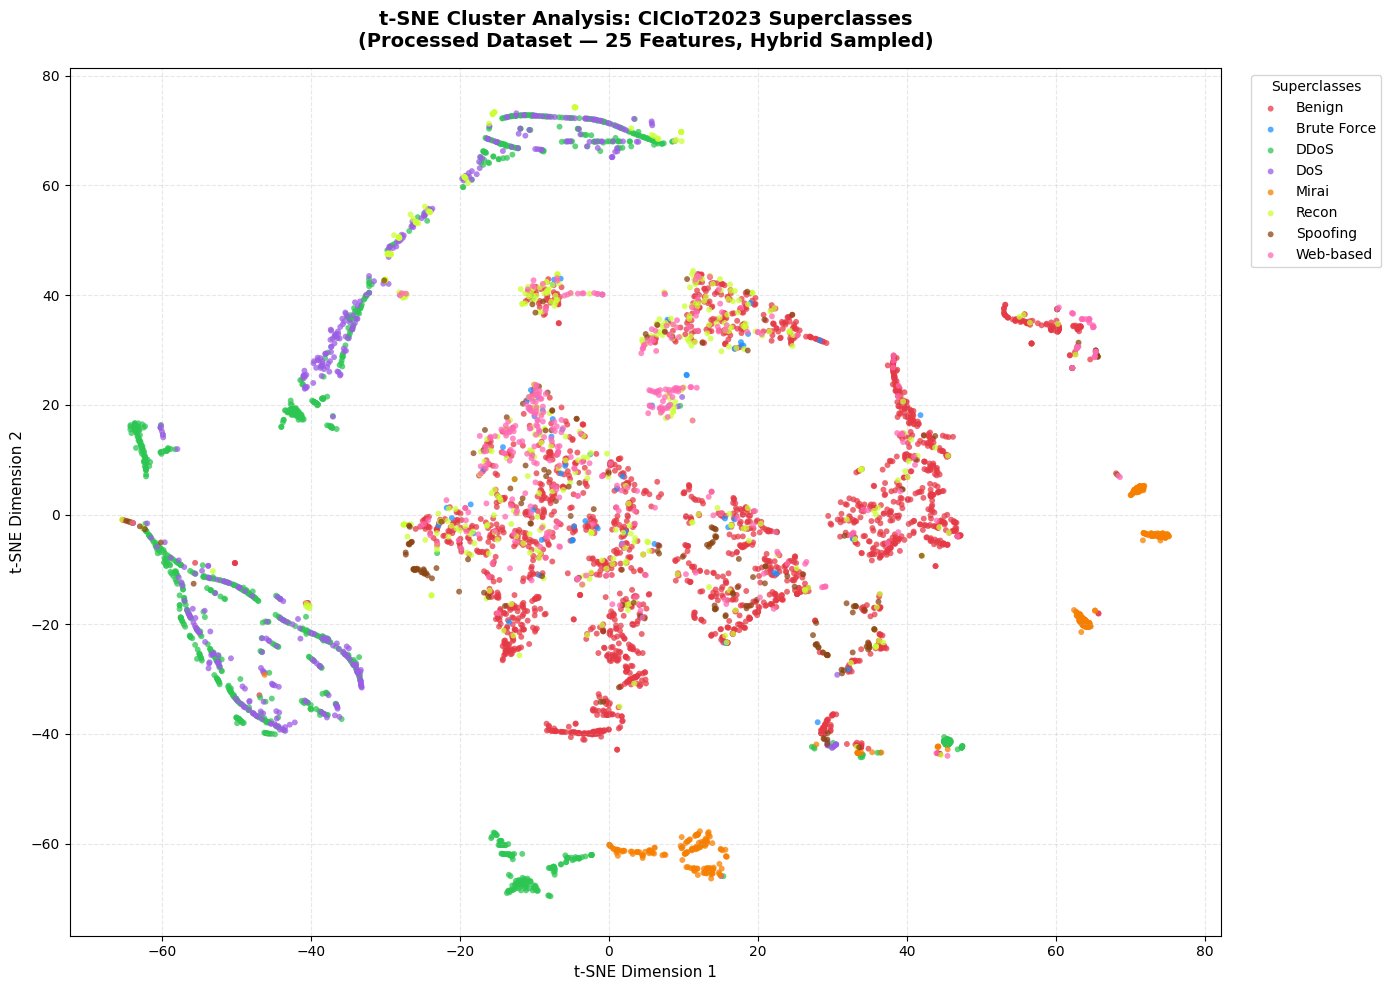

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid50-30)/tsne_superclass_processed.png


In [8]:
# ─── Cell 4: Plot ──────────────────────────────────────────────────────────────
# High contrast color palette — same style as your original plot
palette = {
    'Benign'     : '#E63946',   # red
    'DDoS'       : '#2DC653',   # green
    'DoS'        : '#9B5DE5',   # purple
    'Mirai'      : '#F77F00',   # orange
    'Recon'      : '#CCFF33',   # yellow-green
    'Spoofing'   : '#8B4513',   # brown
    'Web-based'  : '#FF69B4',   # pink
    'Brute Force': '#1E90FF',   # blue
}

fig, ax = plt.subplots(figsize=(14, 10))

for superclass, group in tsne_df.groupby('Superclass'):
    color = palette.get(superclass, '#AAAAAA')
    ax.scatter(
        group['x'], group['y'],
        label=superclass,
        c=color,
        s=18,
        alpha=0.75,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Cluster Analysis: CICIoT2023 Superclasses\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(
    title='Superclasses',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    fontsize=10
)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid50-30)/tsne_superclass_processed.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path}")

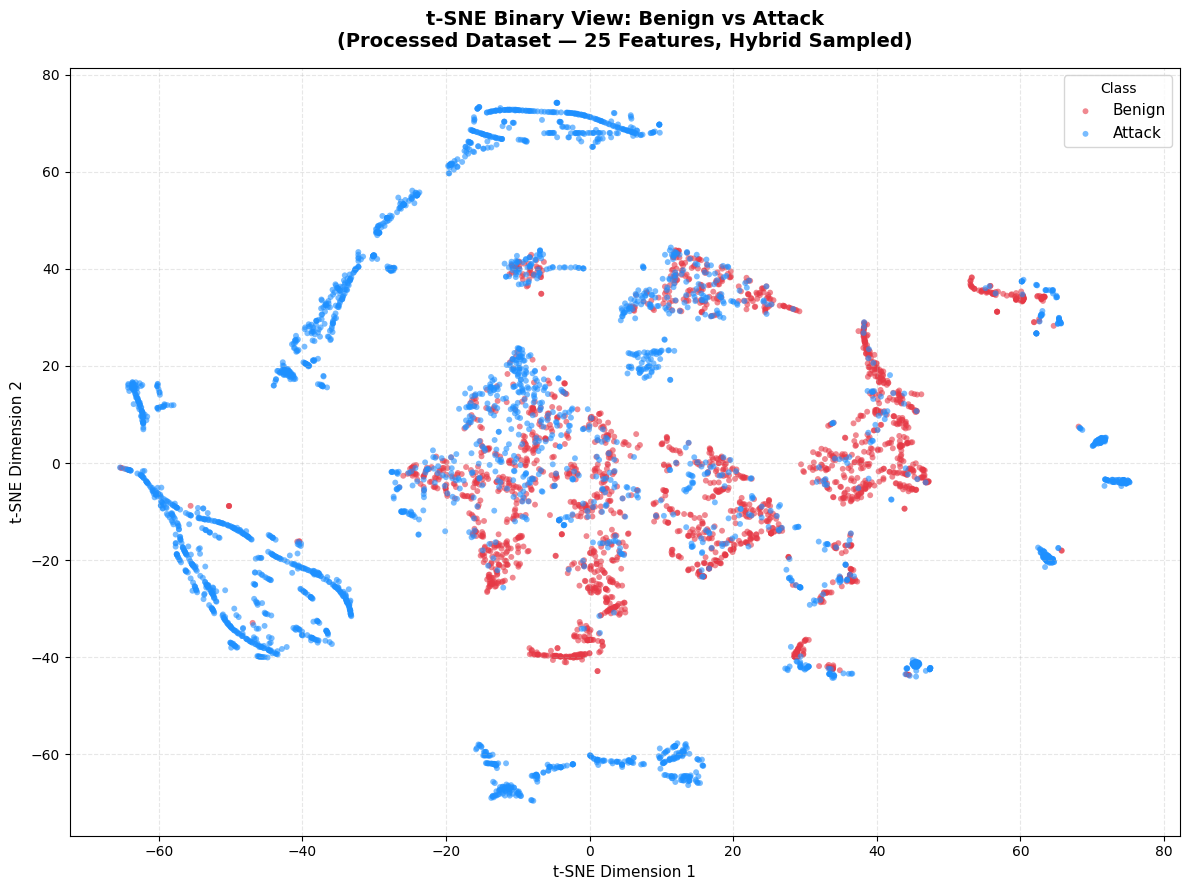

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid50-30)/tsne_binary_processed.png


In [9]:
# ─── Cell 5: Binary View (Benign vs Attack) ────────────────────────────────────
# Useful to directly see how separable benign is from attacks
fig, ax = plt.subplots(figsize=(12, 9))

binary_palette = {0: '#E63946', 1: '#1E90FF'}
binary_labels  = df_sample['Binary_Label'].values
binary_names   = {0: 'Benign', 1: 'Attack'}

for val, name in binary_names.items():
    mask = binary_labels == val
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=name,
        c=binary_palette[val],
        s=18,
        alpha=0.6,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Binary View: Benign vs Attack\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(title='Class', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

save_path_bin = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid50-30)/tsne_binary_processed.png'
plt.savefig(save_path_bin, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path_bin}")

In [10]:
# ─── Cell 1: Install & Imports ─────────────────────────────────────────────────
!pip install scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ─── Cell 2: Load & Sample ─────────────────────────────────────────────────────
file_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled(11)/preprocessed_dataset_with_shadow.csv'

print("📂 Loading preprocessed dataset...")
df = pd.read_csv(file_path)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📊 Superclass Distribution:\n{df['Superclass'].value_counts().to_string()}")

# Sample for t-SNE (full dataset is too large, 3000-5000 is ideal)
# Stratified sample so every superclass is represented proportionally
SAMPLE_SIZE = 5000
df_sample = (
    df.groupby('Superclass', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))
)
# Top up to exactly SAMPLE_SIZE if rounding left us short
if len(df_sample) < SAMPLE_SIZE:
    remaining = df.drop(df_sample.index).sample(SAMPLE_SIZE - len(df_sample), random_state=42)
    df_sample = pd.concat([df_sample, remaining])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_sample.drop(columns=['Binary_Label', 'Superclass', 'Fine_Label'])
labels = df_sample['Superclass']

print(f"\n✅ Sample size for t-SNE: {len(df_sample):,}")
print(f"📊 Sample distribution:\n{labels.value_counts().to_string()}")

📂 Loading preprocessed dataset...
✅ Loaded: 2,053,251 rows × 18 columns
📊 Superclass Distribution:
Superclass
Benign         1026628
DDoS            616911
DoS             192580
Mirai           108027
Recon            31805
Web-based        23243
Spoofing         19851
Brute Force      12294


/tmp/ipykernel_13882/3186886153.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))



✅ Sample size for t-SNE: 5,000
📊 Sample distribution:
Superclass
Benign         2529
DDoS           1519
DoS             475
Mirai           265
Recon            79
Web-based        56
Spoofing         48
Brute Force      29


In [11]:
# ─── Cell 3: Run t-SNE ─────────────────────────────────────────────────────────
print("⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_tsne = tsne.fit_transform(X)
print(f"✅ t-SNE complete! KL divergence: {tsne.kl_divergence_:.4f}")

# Store in df for easy plotting
tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Superclass': labels.values
})

⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.010s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.404s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.228147
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.080250
[t-SNE] KL divergence after 1000 iterations: 0.648987
✅ t-SNE complete! KL divergence: 0.6490


In [12]:
# ─── Cell 3: Run t-SNE ─────────────────────────────────────────────────────────
print("⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_tsne = tsne.fit_transform(X)
print(f"✅ t-SNE complete! KL divergence: {tsne.kl_divergence_:.4f}")

# Store in df for easy plotting
tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Superclass': labels.values
})

⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.010s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.346s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.228147
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.080250
[t-SNE] KL divergence after 1000 iterations: 0.648987
✅ t-SNE complete! KL divergence: 0.6490


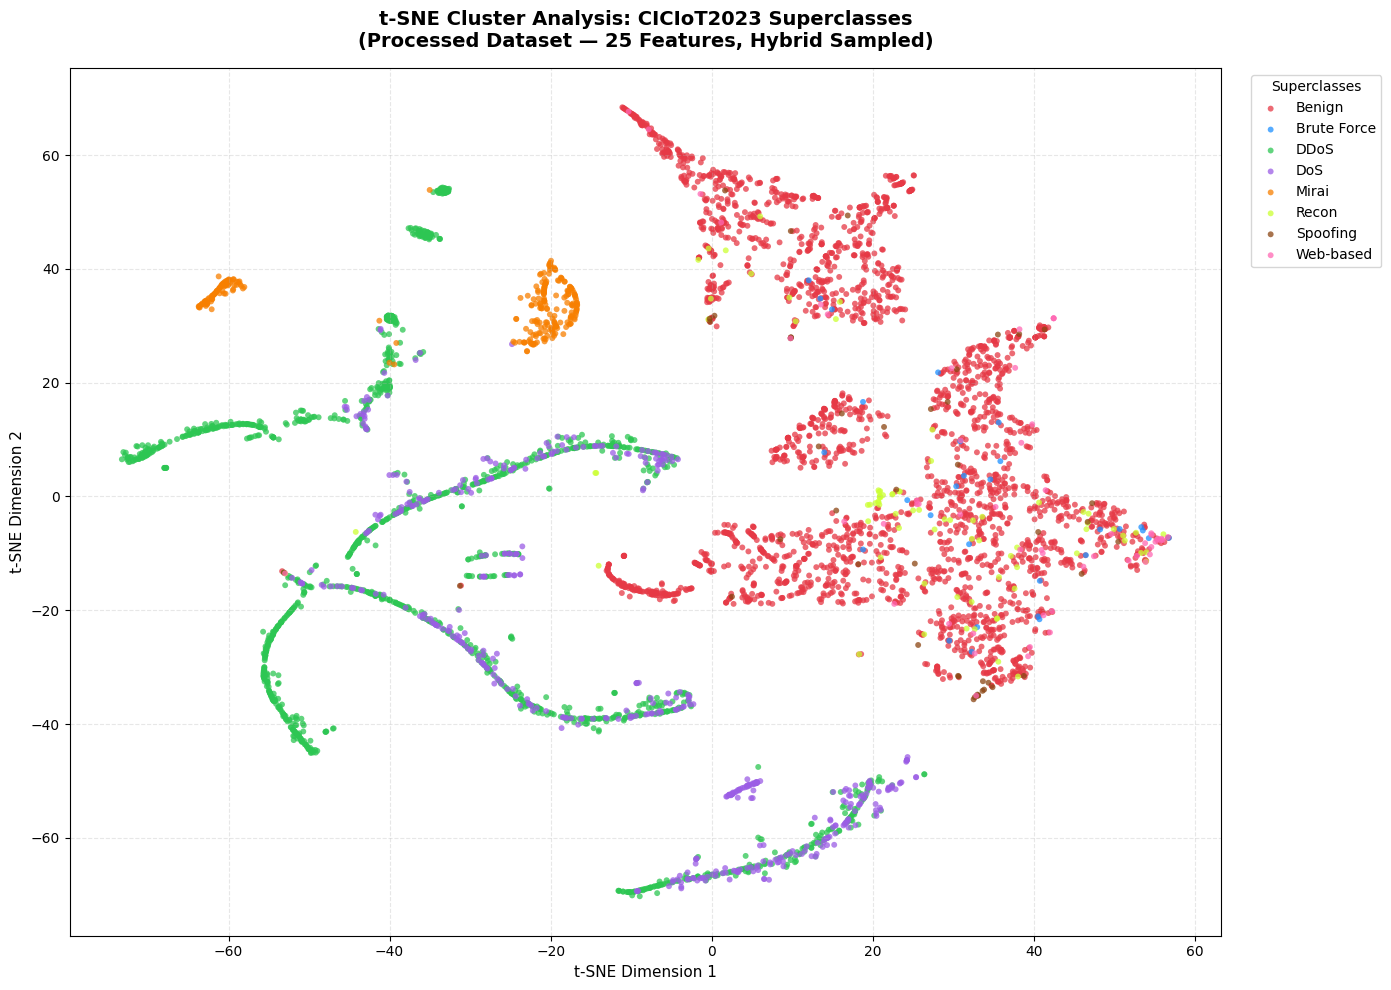

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled(11)/tsne_superclass_processed.png


In [13]:
# ─── Cell 4: Plot ──────────────────────────────────────────────────────────────
# High contrast color palette — same style as your original plot
palette = {
    'Benign'     : '#E63946',   # red
    'DDoS'       : '#2DC653',   # green
    'DoS'        : '#9B5DE5',   # purple
    'Mirai'      : '#F77F00',   # orange
    'Recon'      : '#CCFF33',   # yellow-green
    'Spoofing'   : '#8B4513',   # brown
    'Web-based'  : '#FF69B4',   # pink
    'Brute Force': '#1E90FF',   # blue
}

fig, ax = plt.subplots(figsize=(14, 10))

for superclass, group in tsne_df.groupby('Superclass'):
    color = palette.get(superclass, '#AAAAAA')
    ax.scatter(
        group['x'], group['y'],
        label=superclass,
        c=color,
        s=18,
        alpha=0.75,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Cluster Analysis: CICIoT2023 Superclasses\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(
    title='Superclasses',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    fontsize=10
)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled(11)/tsne_superclass_processed.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path}")

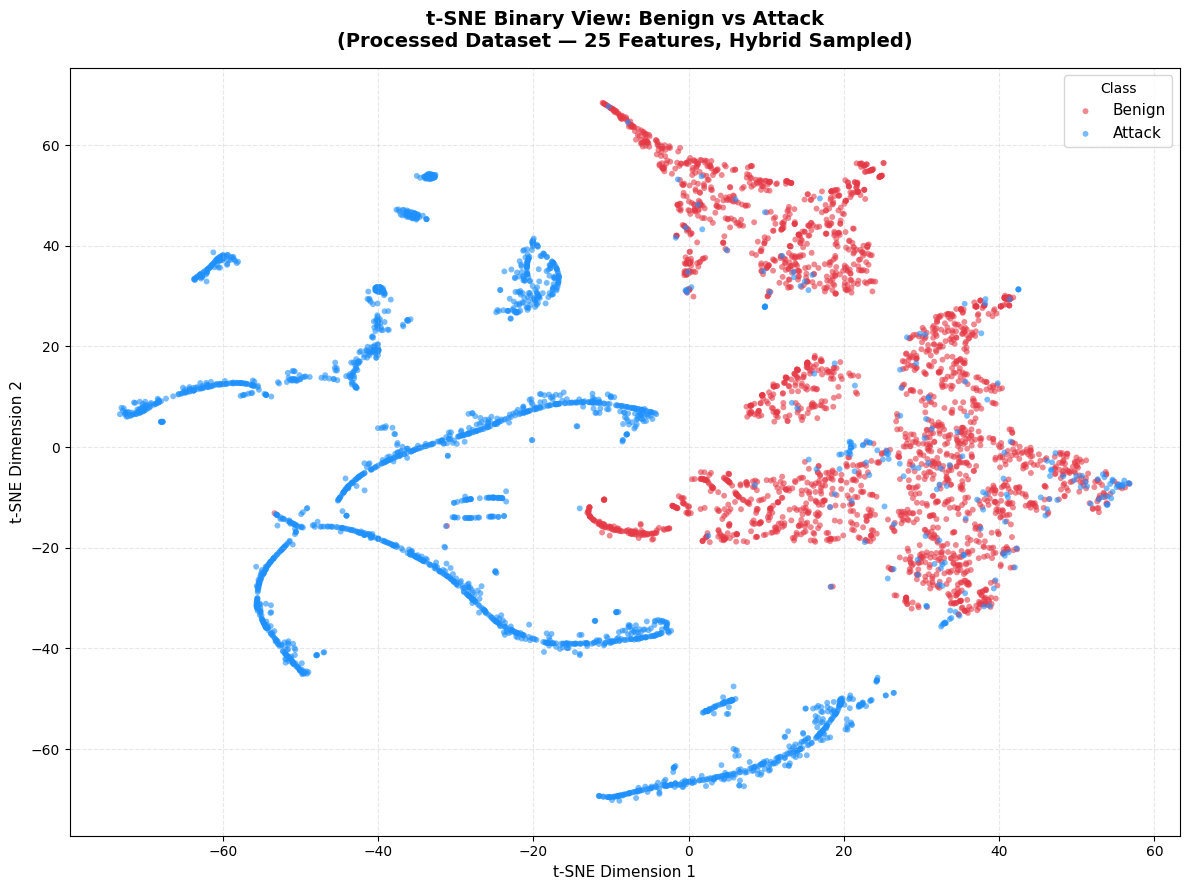

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled(11)/tsne_binary_processed.png


In [14]:
# ─── Cell 5: Binary View (Benign vs Attack) ────────────────────────────────────
# Useful to directly see how separable benign is from attacks
fig, ax = plt.subplots(figsize=(12, 9))

binary_palette = {0: '#E63946', 1: '#1E90FF'}
binary_labels  = df_sample['Binary_Label'].values
binary_names   = {0: 'Benign', 1: 'Attack'}

for val, name in binary_names.items():
    mask = binary_labels == val
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=name,
        c=binary_palette[val],
        s=18,
        alpha=0.6,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Binary View: Benign vs Attack\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(title='Class', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

save_path_bin = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled(11)/tsne_binary_processed.png'
plt.savefig(save_path_bin, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path_bin}")

In [15]:
# ─── Cell 1: Install & Imports ─────────────────────────────────────────────────
!pip install scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ─── Cell 2: Load & Sample ─────────────────────────────────────────────────────
file_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled(1:1)/preprocessed_dataset_with_shadow.csv'

print("📂 Loading preprocessed dataset...")
df = pd.read_csv(file_path)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📊 Superclass Distribution:\n{df['Superclass'].value_counts().to_string()}")

# Sample for t-SNE (full dataset is too large, 3000-5000 is ideal)
# Stratified sample so every superclass is represented proportionally
SAMPLE_SIZE = 5000
df_sample = (
    df.groupby('Superclass', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))
)
# Top up to exactly SAMPLE_SIZE if rounding left us short
if len(df_sample) < SAMPLE_SIZE:
    remaining = df.drop(df_sample.index).sample(SAMPLE_SIZE - len(df_sample), random_state=42)
    df_sample = pd.concat([df_sample, remaining])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_sample.drop(columns=['Binary_Label', 'Superclass', 'Fine_Label'])
labels = df_sample['Superclass']

print(f"\n✅ Sample size for t-SNE: {len(df_sample):,}")
print(f"📊 Sample distribution:\n{labels.value_counts().to_string()}")

📂 Loading preprocessed dataset...
✅ Loaded: 2,053,248 rows × 18 columns
📊 Superclass Distribution:
Superclass
Benign         1026628
DDoS            642834
DoS             209453
Mirai           117480
Recon            32383
Spoofing         21583
Web-based         1162
Brute Force        621


/tmp/ipykernel_13882/504648896.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))



✅ Sample size for t-SNE: 5,000
📊 Sample distribution:
Superclass
Benign         2503
DDoS           1568
DoS             510
Mirai           286
Recon            78
Spoofing         52
Web-based         2
Brute Force       1


In [16]:
# ─── Cell 3: Run t-SNE ─────────────────────────────────────────────────────────
print("⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_tsne = tsne.fit_transform(X)
print(f"✅ t-SNE complete! KL divergence: {tsne.kl_divergence_:.4f}")

# Store in df for easy plotting
tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Superclass': labels.values
})

⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.011s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.393s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.238586
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.130196
[t-SNE] KL divergence after 1000 iterations: 0.674713
✅ t-SNE complete! KL divergence: 0.6747


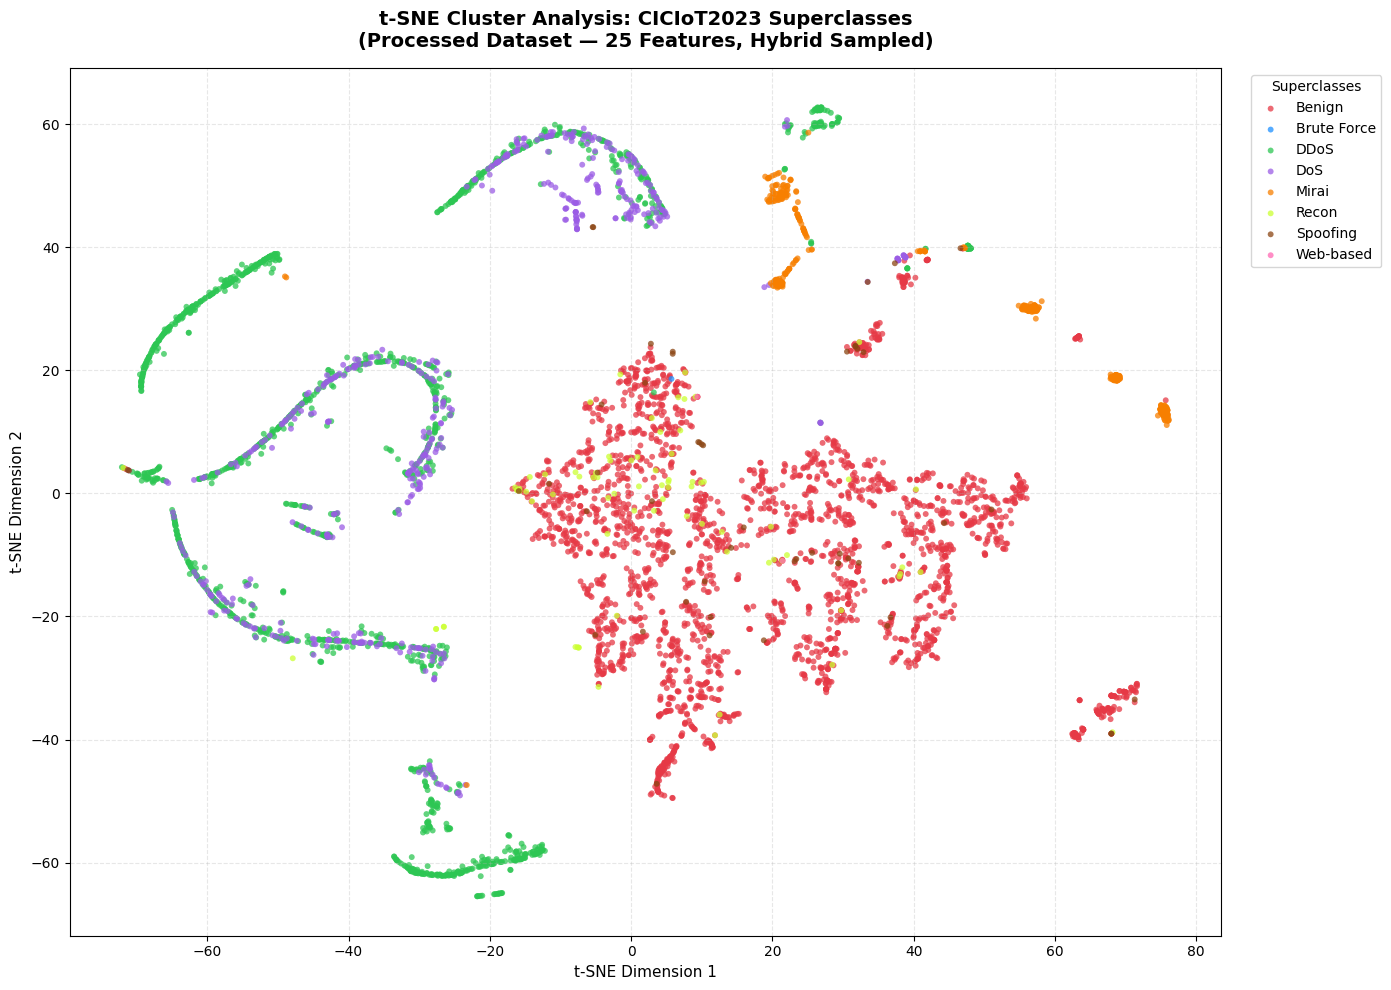

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled(1:1)/tsne_superclass_processed.png


In [17]:
# ─── Cell 4: Plot ──────────────────────────────────────────────────────────────
# High contrast color palette — same style as your original plot
palette = {
    'Benign'     : '#E63946',   # red
    'DDoS'       : '#2DC653',   # green
    'DoS'        : '#9B5DE5',   # purple
    'Mirai'      : '#F77F00',   # orange
    'Recon'      : '#CCFF33',   # yellow-green
    'Spoofing'   : '#8B4513',   # brown
    'Web-based'  : '#FF69B4',   # pink
    'Brute Force': '#1E90FF',   # blue
}

fig, ax = plt.subplots(figsize=(14, 10))

for superclass, group in tsne_df.groupby('Superclass'):
    color = palette.get(superclass, '#AAAAAA')
    ax.scatter(
        group['x'], group['y'],
        label=superclass,
        c=color,
        s=18,
        alpha=0.75,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Cluster Analysis: CICIoT2023 Superclasses\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(
    title='Superclasses',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    fontsize=10
)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled(1:1)/tsne_superclass_processed.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path}")

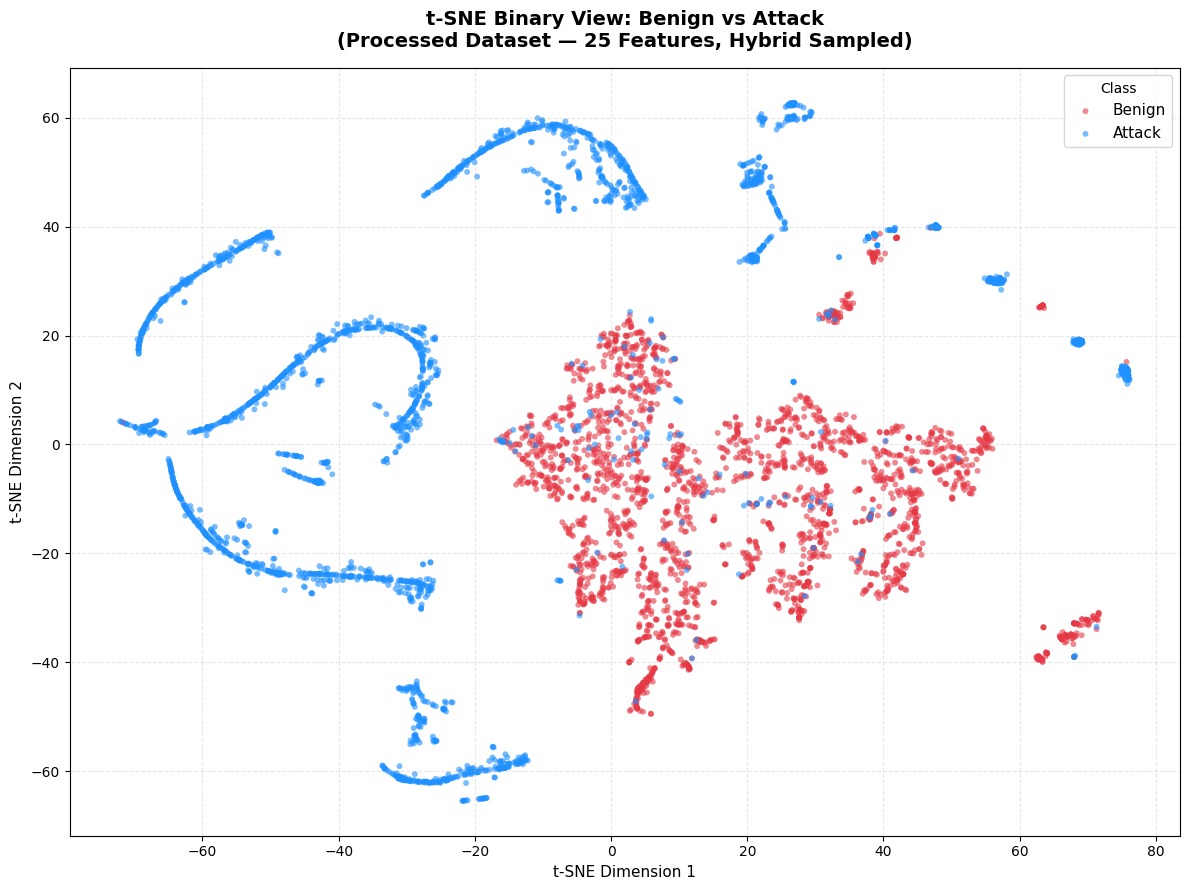

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled(1:1)/tsne_binary_processed.png


In [18]:
# ─── Cell 5: Binary View (Benign vs Attack) ────────────────────────────────────
# Useful to directly see how separable benign is from attacks
fig, ax = plt.subplots(figsize=(12, 9))

binary_palette = {0: '#E63946', 1: '#1E90FF'}
binary_labels  = df_sample['Binary_Label'].values
binary_names   = {0: 'Benign', 1: 'Attack'}

for val, name in binary_names.items():
    mask = binary_labels == val
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=name,
        c=binary_palette[val],
        s=18,
        alpha=0.6,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Binary View: Benign vs Attack\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(title='Class', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

save_path_bin = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled(1:1)/tsne_binary_processed.png'
plt.savefig(save_path_bin, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path_bin}")

In [19]:
# ─── Cell 1: Install & Imports ─────────────────────────────────────────────────
!pip install scikit-learn matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ─── Cell 2: Load & Sample ─────────────────────────────────────────────────────
file_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/preprocessed_dataset_with_shadow.csv'

print("📂 Loading preprocessed dataset...")
df = pd.read_csv(file_path)
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📊 Superclass Distribution:\n{df['Superclass'].value_counts().to_string()}")

# Sample for t-SNE (full dataset is too large, 3000-5000 is ideal)
# Stratified sample so every superclass is represented proportionally
SAMPLE_SIZE = 5000
df_sample = (
    df.groupby('Superclass', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))
)
# Top up to exactly SAMPLE_SIZE if rounding left us short
if len(df_sample) < SAMPLE_SIZE:
    remaining = df.drop(df_sample.index).sample(SAMPLE_SIZE - len(df_sample), random_state=42)
    df_sample = pd.concat([df_sample, remaining])

df_sample = df_sample.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_sample.drop(columns=['Binary_Label', 'Superclass', 'Fine_Label'])
labels = df_sample['Superclass']

print(f"\n✅ Sample size for t-SNE: {len(df_sample):,}")
print(f"📊 Sample distribution:\n{labels.value_counts().to_string()}")

📂 Loading preprocessed dataset...
✅ Loaded: 2,346,628 rows × 18 columns
📊 Superclass Distribution:
Superclass
Benign         1026628
DDoS            440000
Web-based       240000
Recon           200000
DoS             160000
Mirai           120000
Spoofing         80000
Brute Force      40000


/tmp/ipykernel_13882/454718648.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42))



✅ Sample size for t-SNE: 5,000
📊 Sample distribution:
Superclass
Benign         2229
DDoS            951
Web-based       519
Recon           437
DoS             342
Mirai           262
Spoofing        173
Brute Force      86


In [20]:
# ─── Cell 3: Run t-SNE ─────────────────────────────────────────────────────────
print("⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes")

tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

X_tsne = tsne.fit_transform(X)
print(f"✅ t-SNE complete! KL divergence: {tsne.kl_divergence_:.4f}")

# Store in df for easy plotting
tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Superclass': labels.values
})

⏳ Running t-SNE (perplexity=40, n_iter=1000)... this may take a few minutes
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.010s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.452s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.569778
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.732056
[t-SNE] KL divergence after 1000 iterations: 0.654192
✅ t-SNE complete! KL divergence: 0.6542


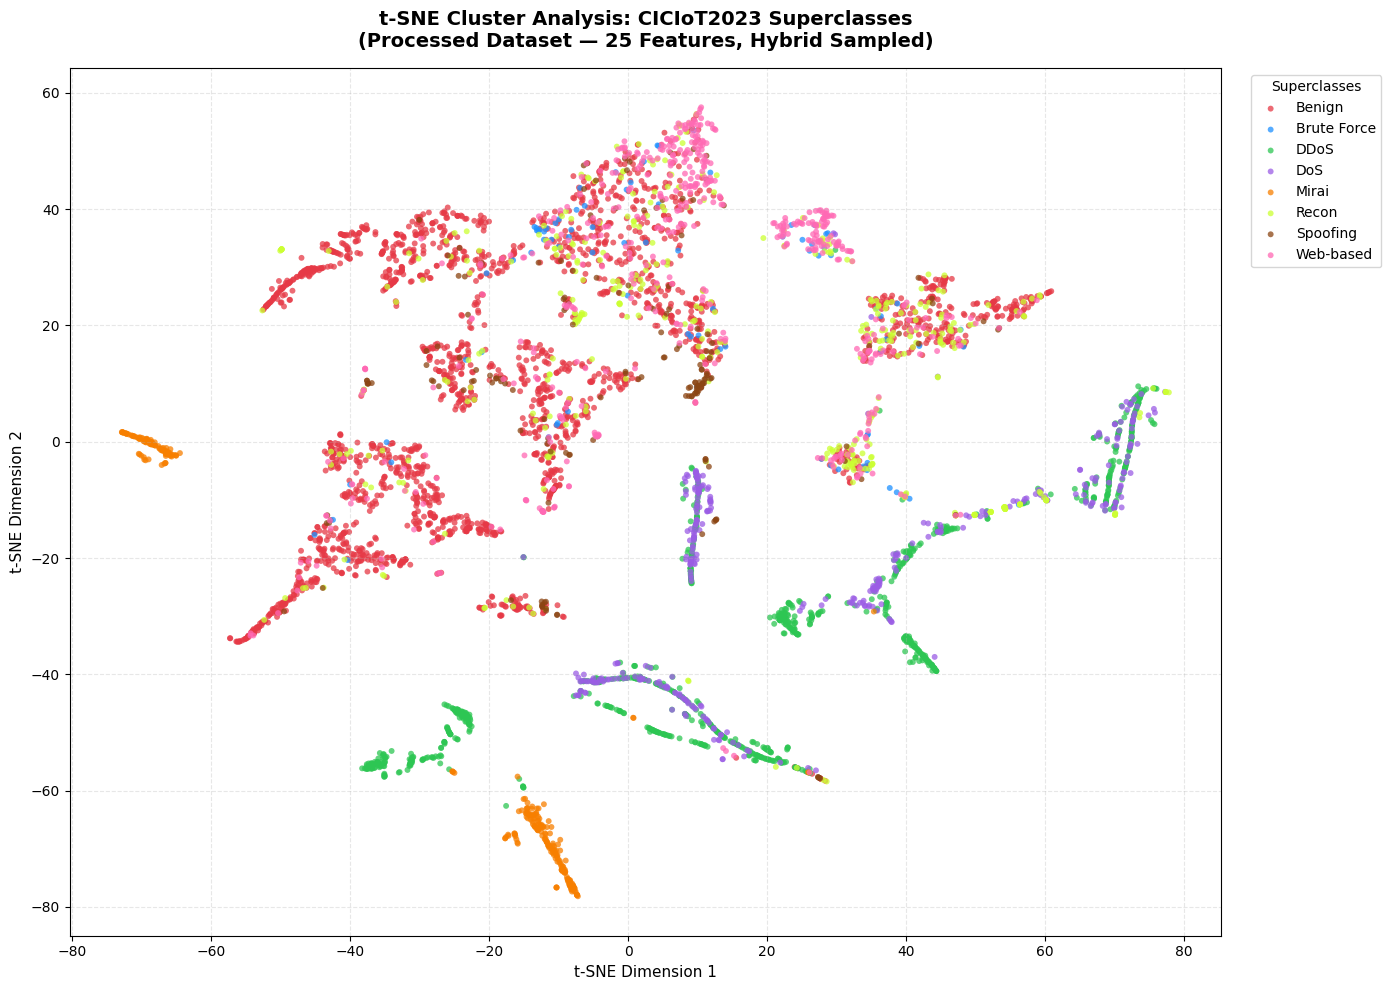

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/tsne_superclass_processed.png


In [21]:
# ─── Cell 4: Plot ──────────────────────────────────────────────────────────────
# High contrast color palette — same style as your original plot
palette = {
    'Benign'     : '#E63946',   # red
    'DDoS'       : '#2DC653',   # green
    'DoS'        : '#9B5DE5',   # purple
    'Mirai'      : '#F77F00',   # orange
    'Recon'      : '#CCFF33',   # yellow-green
    'Spoofing'   : '#8B4513',   # brown
    'Web-based'  : '#FF69B4',   # pink
    'Brute Force': '#1E90FF',   # blue
}

fig, ax = plt.subplots(figsize=(14, 10))

for superclass, group in tsne_df.groupby('Superclass'):
    color = palette.get(superclass, '#AAAAAA')
    ax.scatter(
        group['x'], group['y'],
        label=superclass,
        c=color,
        s=18,
        alpha=0.75,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Cluster Analysis: CICIoT2023 Superclasses\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(
    title='Superclasses',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    fontsize=10
)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save
save_path = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/tsne_superclass_processed.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path}")

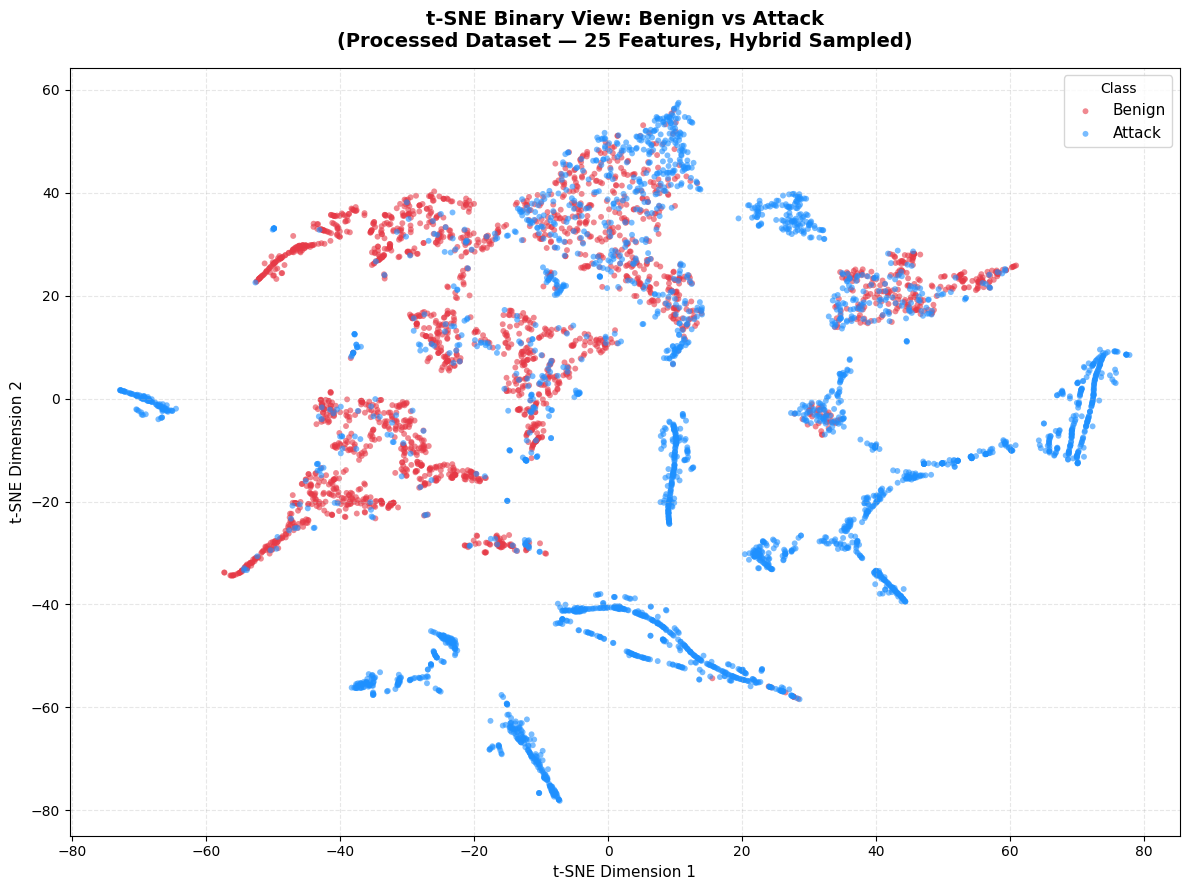

✅ Saved to: /content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/tsne_binary_processed.png


In [22]:
# ─── Cell 5: Binary View (Benign vs Attack) ────────────────────────────────────
# Useful to directly see how separable benign is from attacks
fig, ax = plt.subplots(figsize=(12, 9))

binary_palette = {0: '#E63946', 1: '#1E90FF'}
binary_labels  = df_sample['Binary_Label'].values
binary_names   = {0: 'Benign', 1: 'Attack'}

for val, name in binary_names.items():
    mask = binary_labels == val
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        label=name,
        c=binary_palette[val],
        s=18,
        alpha=0.6,
        edgecolors='none'
    )

ax.set_title(
    't-SNE Binary View: Benign vs Attack\n(Processed Dataset — 25 Features, Hybrid Sampled)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(title='Class', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

save_path_bin = '/content/drive/MyDrive/final_dataset/iot_cleaned_sampled_smote(hybrid40-40)/tsne_binary_processed.png'
plt.savefig(save_path_bin, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {save_path_bin}")